# Interactive Molecular Screening Pipeline - Test & Demonstration

This notebook provides an interactive dashboard to customize a cationic scaffold, apply structural constraints, and run the full generative and predictive screening pipeline.

### Pipeline Workflow

1. **Combinatorial Generation & UI Interaction** (`.generation()`)
   * **Interactive Setup:** If no scaffold is pre-set, calling this method launches the interactive visual widget environment to choose a base cation, cut specific atom indices, and configure local anchor symmetries/groups dynamically.
   * **Library Expansion:** Automatically generates the library of functionalized cations based on allowed functional groups and local connection rules using package-relative database paths.
2. **Synthetic Accessibility Filtering** (`.sascore()` & `.pair_with_anions()`)
   Computes **SAScores** via RDKit and discards any structures with a score $> 6.0$. Surviving cations are then cross-paired with the standard anion library to build the complete salt matrix.
3. **Deep Learning $T_m$ Prediction** (`.tm()`)
   Extracts high-dimensional Mordred descriptors for both ions and calls the ensemble fold layers of the pre-trained **Parallel-Scaffold CNN (PSCNN)** neural networks.
4. **Thermal Filtering & Visual Reporting** (`.heatmap()` & `.show()`)
   Retains only low-melting salts ($T_m \le 100^\circ\text{C}$) and renders automated visual reports (matrix heatmaps, violin family distributions, or 2D chemical structure grids).
5.  **Data Exporting** (`.save()`) This utility method allows you to dump the internal pipeline state (`self.df`) into physical files at any specific milestone of your screening workflow without breaking method chaining.
* **Format Flexibility:** Automatically detects and handles standard Comma-Separated Values (`.csv`) and Microsoft Excel (`.xlsx`) files based on your provided extension.
* **Selective Column Filtering:** By utilizing the optional `columns` argument, you can restrict the output file size to only include target chemical attributes of interest:
  * *Post-Generation:* Save just the generated topological paths (`columns=["cation_smiles"]`).
  * *Post-SAScore:* Save paired matrices alongside structural strain indices (`columns=["cation_smiles", "anion_smiles", "sascore"]`).
  * *Post-Inference:* Export full analytical properties including CNN predictions (`columns=["cation_smiles", "anion_smiles", "sascore", "predicted_tm"]`).
---


In [17]:
import sys
import os

%load_ext autoreload
%autoreload 2
    
sys.path.append(os.path.abspath('../'))

from ils_screening_tm.main import ILsScreening

ils = ILsScreening()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


###  Combinatorial Generation & UI Framework (`.generation()`)

This method serves as the orchestrator for the structural setup and library functionalization of your cations. 

* **If executed without a predefined scaffold:** It dynamically spins up an interactive `ipywidgets` dashboard directly inside the cell. This user interface allows you to select a base chemical family (Imidazolium, Pyridinium, etc.), cut specific atom indices to create new substitution sites, and define dynamic structural symmetries/anchor groups.
* **Core Computational Logic:** Once the scaffold choices are validated, the generation engine executes a combinatorial substitution workflow. It pairs the vacant anchor positions with your defined substituent libraries, filtering out chemically invalid structures using internal SMARTS structural constraints.

*The results are registered in memory inside the pipeline's internal state (`self.df`), bypassing intermediate disk write overheads.*

In [18]:
ils.generation()

💡 No scaffold layout defined. Launching interactive Widget interface...


Label(value='🔧 Screening Bounds Settings:')

Dropdown(description='Cation Core:', options=(('Pyrrolidinium', 0), ('Pyridinium', 1), ('Piperidinium', 2), ('…

Output()

ILsScreening Pipeline (Status: Empty Sandbox)

###  High-Resolution Molecular Structure Rendering (`.show()`)

Once the filtering and deep learning predictions are complete, this method provides a direct visual validation of the structural output.

* **Randomized Sub-Sampling:** To avoid crashing the notebook interface or overwhelming the user with thousands of rows, `sample_size` extracts a clean, randomized subset of the final screened dataset.
* **Dual-Ion Visual Grid:** It utilizes RDKit's rendering engine to draw clean 2D chemical structures, automatically pairing each surviving cation right alongside its corresponding counter-anion. 
* **Properties Overlay:** Each molecular tile in the grid is annotated with its final computed screening attributes (such as predicted $T_m$ and SAScore) for rapid visual auditing.

🎨 Displaying 5 random generated Cations structures:


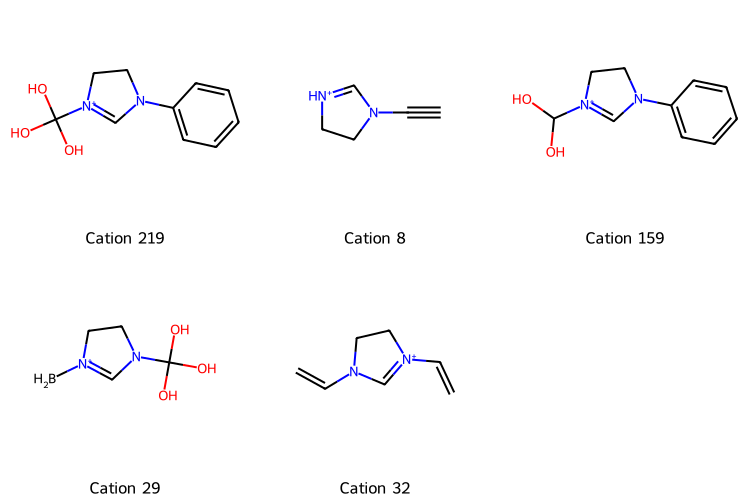

ILsScreening Pipeline (Status: Generated Cations Registry (121 structures))

In [19]:
ils.show(sample_size=5)

### Synthetic Accessibility Filtering & Anion Pairing (`.sascore()`)

This method acts as a strict structural gatekeeper to ensure that only realistic, synthetically viable molecules proceed to the deep learning stage.

* **SAScore Computation:** It evaluates every unique generated cation using RDKit's Synthetic Accessibility (SA) scoring algorithm. The score ranges from 1 (very easy to synthesize) to 10 (extremely difficult/unstable).
* **The Synthesis Gate:** By enforcing `threshold=6.0`, the pipeline instantly discards overly complex, highly strained, or chemically unstable cationic structures.
* **Automated Salt Crossover:** Surviving cations that successfully clear the gate are automatically cross-joined (Cartesian product) with the package's internal standard anion library, instantly expanding the dataset from individual ions into a complete matrix of paired ionic liquid salts.

In [20]:
ils.sascore(threshold=6.0)

🧪 [SAScore] Calculating chemical accessibility vectors...
✂️ [SAScore Filter] 110 / 121 cations retained under threshold (<= 6.0).


ILsScreening Pipeline (Status: Generated Cations Registry (110 structures))

📊 [Visualization] Plotting Cations SAScore distribution histogram...


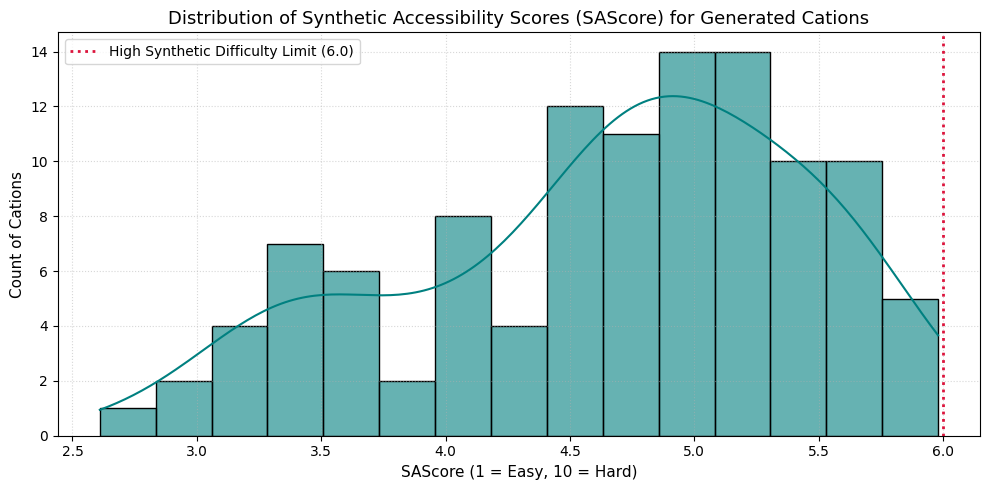

ILsScreening Pipeline (Status: Generated Cations Registry (110 structures))

In [21]:
ils.heatmap(mode='sascore')

### Automated Salt Matrix Crossover (`.pair_with_anions()`)

This method handles the transitional bridge from individual ionic components to complete, realistic salt pairs.

* **Cartesian Product Cross-Join:** It automatically extracts all unique cations that have successfully cleared your previous structural filters and performs a full combinatorial cross-join with the package's internal anion library.
* **Salt Matrix Assembly:** Each row in the internal dataset is transformed from a single cation into a distinct, paired Ionic Liquid (IL) structural matrix entry containing both the explicit cation and anion building blocks.
* **Property Conservation:** It maps and carries over all previously computed descriptors and properties (such as the cation's SAScore) into the newly generated paired salt dataset, preparing it directly for the downstream deep learning prediction layers.

In [7]:
ils.pair_with_anions()

🔗 [Anion Pairing] Matrix built: Generated 986 full salt configurations.


ILsScreening Pipeline (Status: Paired Library (986 salt configurations))

🎨 Displaying 5 random Screened Salt Pairs (Left: Cation | Right: Anion):


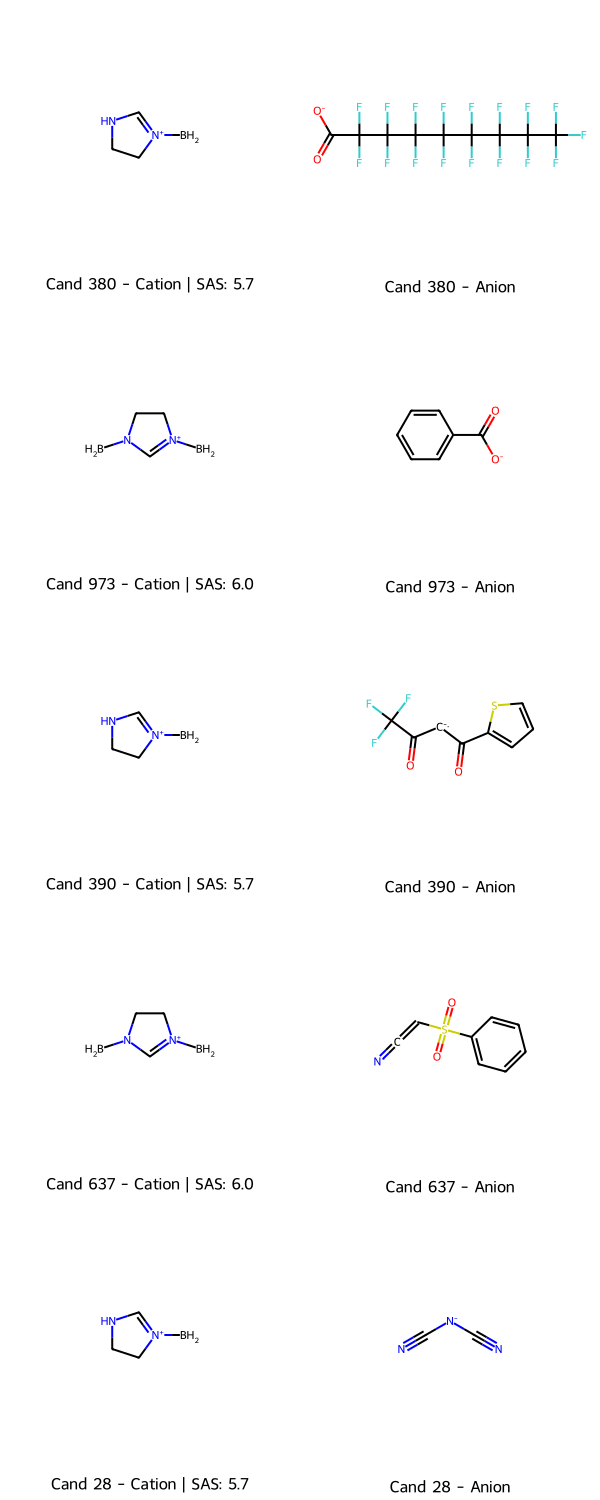

ILsScreening Pipeline (Status: Paired Library (986 salt configurations))

In [8]:
ils.show(sample_size=5)

### Deep Learning Melting Point Prediction (`.tm()`)

This method runs the core predictive engine of the pipeline, using deep learning to forecast the melting point ($T_m$) of the generated ionic liquid matrix.

* **High-Dimensional Feature Extraction:** The pipeline automatically computes 209 mathematical Mordred structural descriptors for both the cation and the anion blocks, standardizing them via pre-trained feature scalers.
* **Parallel-Scaffold CNN Ensemble:** The processed descriptor blocks are fed into a 5-Fold Cross-Validation Ensemble of **Parallel-Scaffold Convolutional Neural Networks (PSCNN)**. This dual-input architecture processes the cation and anion features independently before combining them to predict the final melting point.
* **Thermal Screening:** By applying `threshold_c=100.0`, the pipeline enforces a strict room-temperature/low-melting cutoff. Any paired salt with an ensemble-averaged predicted melting point greater than $100^\circ\text{C}$ is discarded, isolating the top low-melting candidates.

In [9]:
ils.tm(threshold_c=100.0)

Tm Prediction running... Extracting Mordred vectors and calling fold layers...


W0000 00:00:1783002977.454749 1258241 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


/home/lorris/These/spektral_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/lorris/These/spektral_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/lorris/These/spektral_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/lorris/These/spektral_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/lorris/These/spektral_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/lorris/These/s

ILsScreening Pipeline (Status: Screened Library (967 salts with predicted Tm))

🎨 Displaying 5 random Screened Salt Pairs (Left: Cation | Right: Anion):


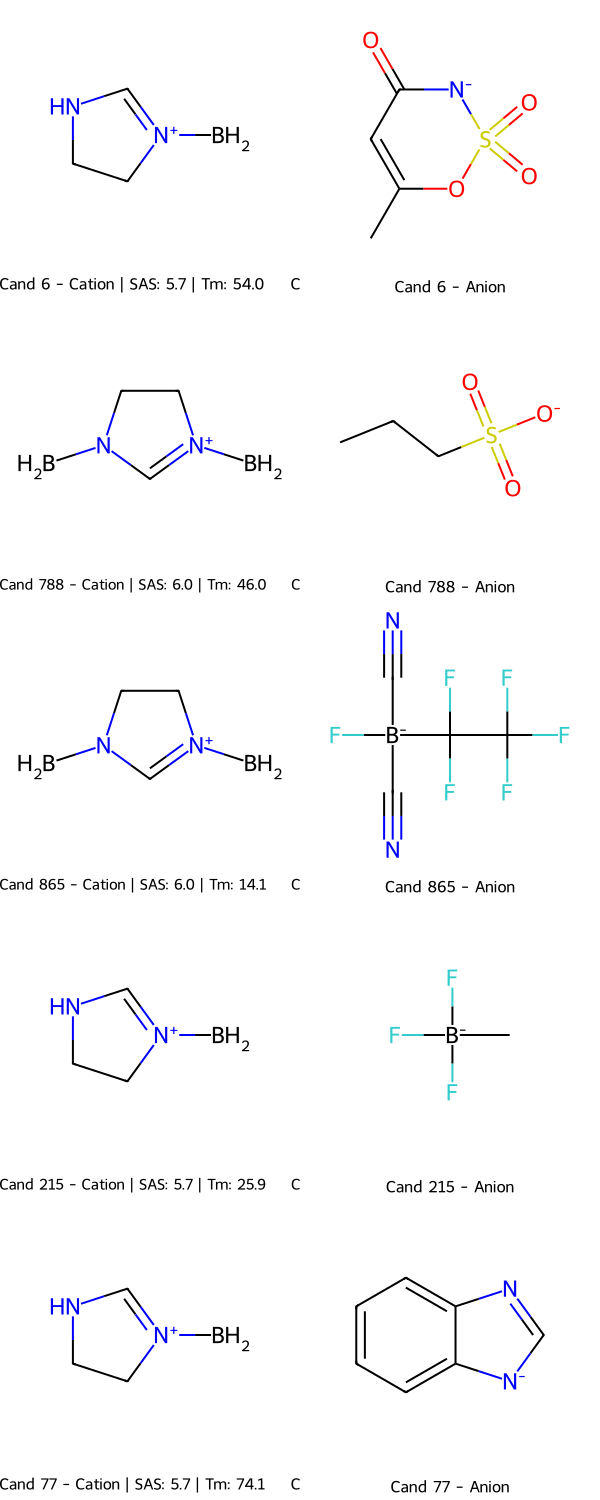

ILsScreening Pipeline (Status: Screened Library (967 salts with predicted Tm))

In [8]:
ils.show(sample_size=5)